In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing

In [2]:
test_df = pd.read_csv("test.csv")
train_df = pd.read_csv("train.csv")

In [7]:
train_df.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')

In [4]:
# Basic info
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nData types:\n{train_df.dtypes}")
print(f"\nMissing values:\n{train_df.isnull().sum()[train_df.isnull().sum() > 0]}")

Train shape: (19237, 18)
Test shape: (8245, 18)

Data types:
ID                    int64
Price                 int64
Levy                    str
Manufacturer            str
Model                   str
Prod. year            int64
Category                str
Leather interior        str
Fuel type               str
Engine volume           str
Mileage                 str
Cylinders           float64
Gear box type           str
Drive wheels            str
Doors                   str
Wheel                   str
Color                   str
Airbags               int64
dtype: object

Missing values:
Series([], dtype: int64)


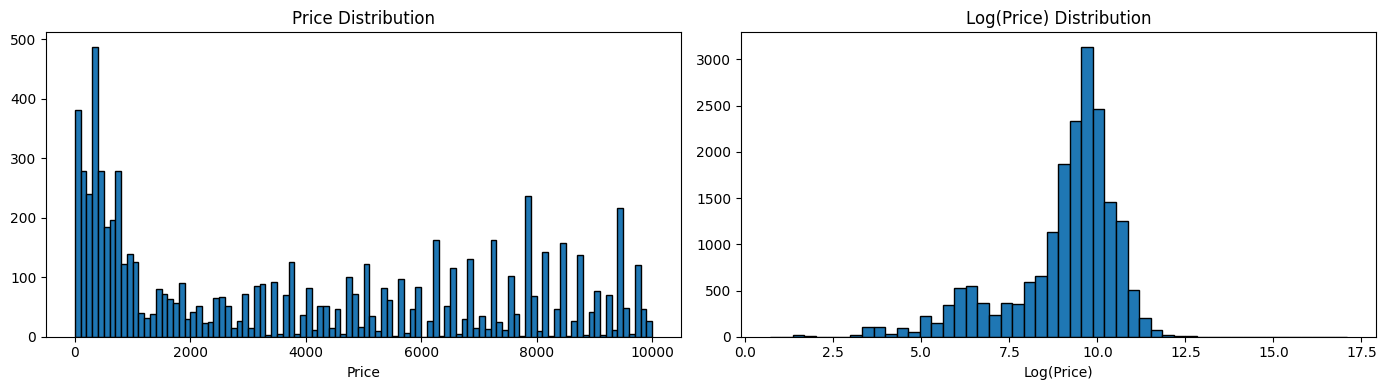

Price stats:
count    1.923700e+04
mean     1.855593e+04
std      1.905813e+05
min      1.000000e+00
25%      5.331000e+03
50%      1.317200e+04
75%      2.207500e+04
max      2.630750e+07
Name: Price, dtype: float64

--- Suspicious low prices ---
Price == 0: 0
Price <= 10: 24
Price <= 100: 381
Price <= 500: 1665

--- Suspicious high prices ---
Price > 100k: 113
Price > 200k: 13

Lowest 15 prices: [np.int64(1), np.int64(1), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]
Highest 10 prices: [np.int64(250574), np.int64(254024), np.int64(260296), np.int64(288521), np.int64(297930), np.int64(297930), np.int64(308906), np.int64(627220), np.int64(872946), np.int64(26307500)]


In [8]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_df[train_df['Price'] <= 10000]['Price'], bins=100, edgecolor='black')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')
axes[1].hist(np.log1p(train_df['Price']), bins=50, edgecolor='black')
axes[1].set_title('Log(Price) Distribution')
axes[1].set_xlabel('Log(Price)')
plt.tight_layout()
plt.show()

# Price stats + suspicious values
print(f"Price stats:\n{train_df['Price'].describe()}")
print(f"\n--- Suspicious low prices ---")
print(f"Price == 0: {(train_df['Price'] == 0).sum()}")
print(f"Price <= 10: {(train_df['Price'] <= 10).sum()}")
print(f"Price <= 100: {(train_df['Price'] <= 100).sum()}")
print(f"Price <= 500: {(train_df['Price'] <= 500).sum()}")
print(f"\n--- Suspicious high prices ---")
print(f"Price > 100k: {(train_df['Price'] > 100_000).sum()}")
print(f"Price > 200k: {(train_df['Price'] > 200_000).sum()}")
print(f"\nLowest 15 prices: {sorted(train_df['Price'].values)[:15]}")
print(f"Highest 10 prices: {sorted(train_df['Price'].values)[-10:]}")

# Wrong and Missing Data

In [9]:
train_clean = train_df.copy()

# Outlier analysis and target transform
print(f"Price == 0: {(train_clean['Price'] == 0).sum()} rows")
print(f"Price < 100: {(train_clean['Price'] < 100).sum()} rows")
print(f"Price > 200k: {(train_clean['Price'] > 200_000).sum()} rows")
print(f"Price > 100k: {(train_clean['Price'] > 100_000).sum()} rows")
print(f"Price percentiles:\n{train_clean['Price'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])}")

# Remove Price < 100 (clearly data errors: Porsche at $3, Mercedes at $1, etc.)
n_low = (train_clean['Price'] < 100).sum()
print(f"\nRemoving {n_low} rows with Price < 100")
train_clean = train_clean[train_clean['Price'] >= 100]

# Log-transform
train_clean['Log_Price'] = np.log1p(train_clean['Price'])

print(f"\nFinal training size: {len(train_clean)}")
print(f"Log_Price stats:\n{train_clean['Log_Price'].describe()}")

Price == 0: 0 rows
Price < 100: 356 rows
Price > 200k: 13 rows
Price > 100k: 113 rows
Price percentiles:
0.01       45.0
0.05      314.0
0.25     5331.0
0.50    13172.0
0.75    22075.0
0.95    49459.0
0.99    84675.0
Name: Price, dtype: float64

Removing 356 rows with Price < 100

Final training size: 18881
Log_Price stats:
count    18881.000000
mean         9.127837
std          1.415929
min          4.615121
25%          8.676928
50%          9.509185
75%         10.024864
max         17.085365
Name: Log_Price, dtype: float64


In [10]:
# Clean and convert columns for analysis

train_clean['Age'] = 2026 - train_clean['Prod. year']
test_df['Age'] = 2026 - test_df['Prod. year']

# Engine volume: extract numeric (some have 'Turbo' suffix)
train_clean['Turbo'] = train_df['Engine volume'].str.contains('Turbo').astype(int)
train_clean['Engine volume'] = train_df['Engine volume'].str.replace(' Turbo', '', regex=False).astype(float)
test_df['Turbo'] = test_df['Engine volume'].str.contains('Turbo').astype(int)
test_df['Engine volume'] = test_df['Engine volume'].str.replace(' Turbo', '', regex=False).astype(float)

# Levy: replace '-' with NaN, track missingness, fill by Engine volume group median
train_clean['Levy'] = train_df['Levy'].replace('-', np.nan).astype(float)
train_clean['Levy_missing'] = train_clean['Levy'].isna().astype(int)
train_clean['Levy'] = train_clean.groupby('Engine volume')['Levy'].transform(
    lambda x: x.fillna(x.median())
)
train_clean['Levy'] = train_clean['Levy'].fillna(train_clean['Levy'].median())

test_df['Levy'] = test_df['Levy'].replace('-', np.nan).astype(float)
test_df['Levy_missing'] = test_df['Levy'].isna().astype(int)
test_df['Levy'] = test_df.groupby('Engine volume')['Levy'].transform(
    lambda x: x.fillna(x.median())
)
test_df['Levy'] = test_df['Levy'].fillna(test_df['Levy'].median())

# Mileage: extract numeric value (remove ' km')
train_clean['Mileage'] = train_df['Mileage'].str.replace(' km', '', regex=False).astype(int)
test_df['Mileage'] = test_df['Mileage'].str.replace(' km', '', regex=False).astype(int)

# Doors: map to numeric
doors_map = {'02-Mar': 3, '04-May': 5, '>5': 6}
train_clean['Doors'] = train_df['Doors'].map(doors_map)
test_df['Doors'] = test_df['Doors'].map(doors_map)

print("Cleaned numeric columns:")
print(train_clean[['Levy', 'Levy_missing', 'Mileage', 'Engine volume', 'Turbo', 'Doors']].describe())

Cleaned numeric columns:
               Levy  Levy_missing       Mileage  Engine volume         Turbo  \
count  18881.000000  18881.000000  1.888100e+04   18881.000000  18881.000000   
mean     897.820428      0.293470  1.384874e+06       2.317202      0.101637   
std      443.241944      0.455364  4.558415e+07       0.878709      0.302178   
min       87.000000      0.000000  0.000000e+00       0.000000      0.000000   
25%      639.000000      0.000000  7.045000e+04       1.800000      0.000000   
50%      781.000000      0.000000  1.260210e+05       2.000000      0.000000   
75%     1036.000000      1.000000  1.890000e+05       2.500000      0.000000   
max    11714.000000      1.000000  2.147484e+09      20.000000      1.000000   

              Doors  
count  18881.000000  
mean       4.924792  
std        0.405550  
min        3.000000  
25%        5.000000  
50%        5.000000  
75%        5.000000  
max        6.000000  


In [11]:
missing_pct = train_clean.isnull().mean().sort_values(ascending=False) * 100
print(missing_pct[missing_pct > 0])

Series([], dtype: float64)


# View Features

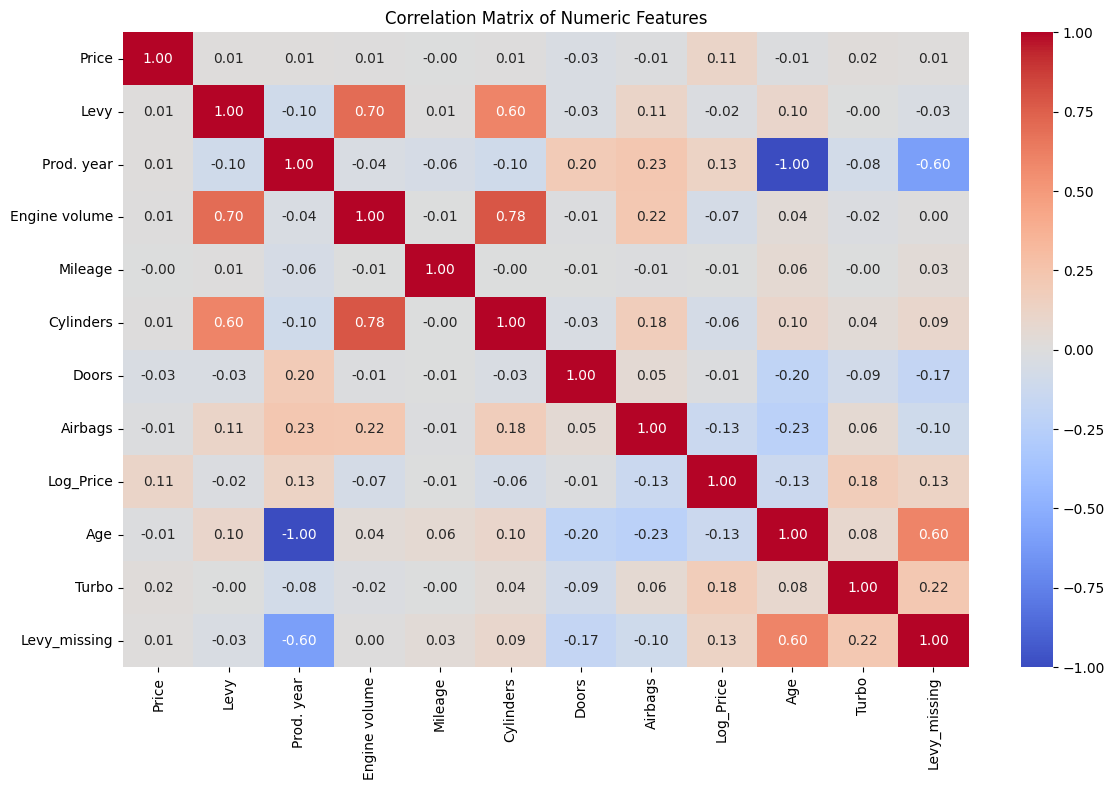

In [12]:
# Correlation heatmap of numeric features
numeric_cols = train_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('ID')

plt.figure(figsize=(12, 8))
corr = train_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

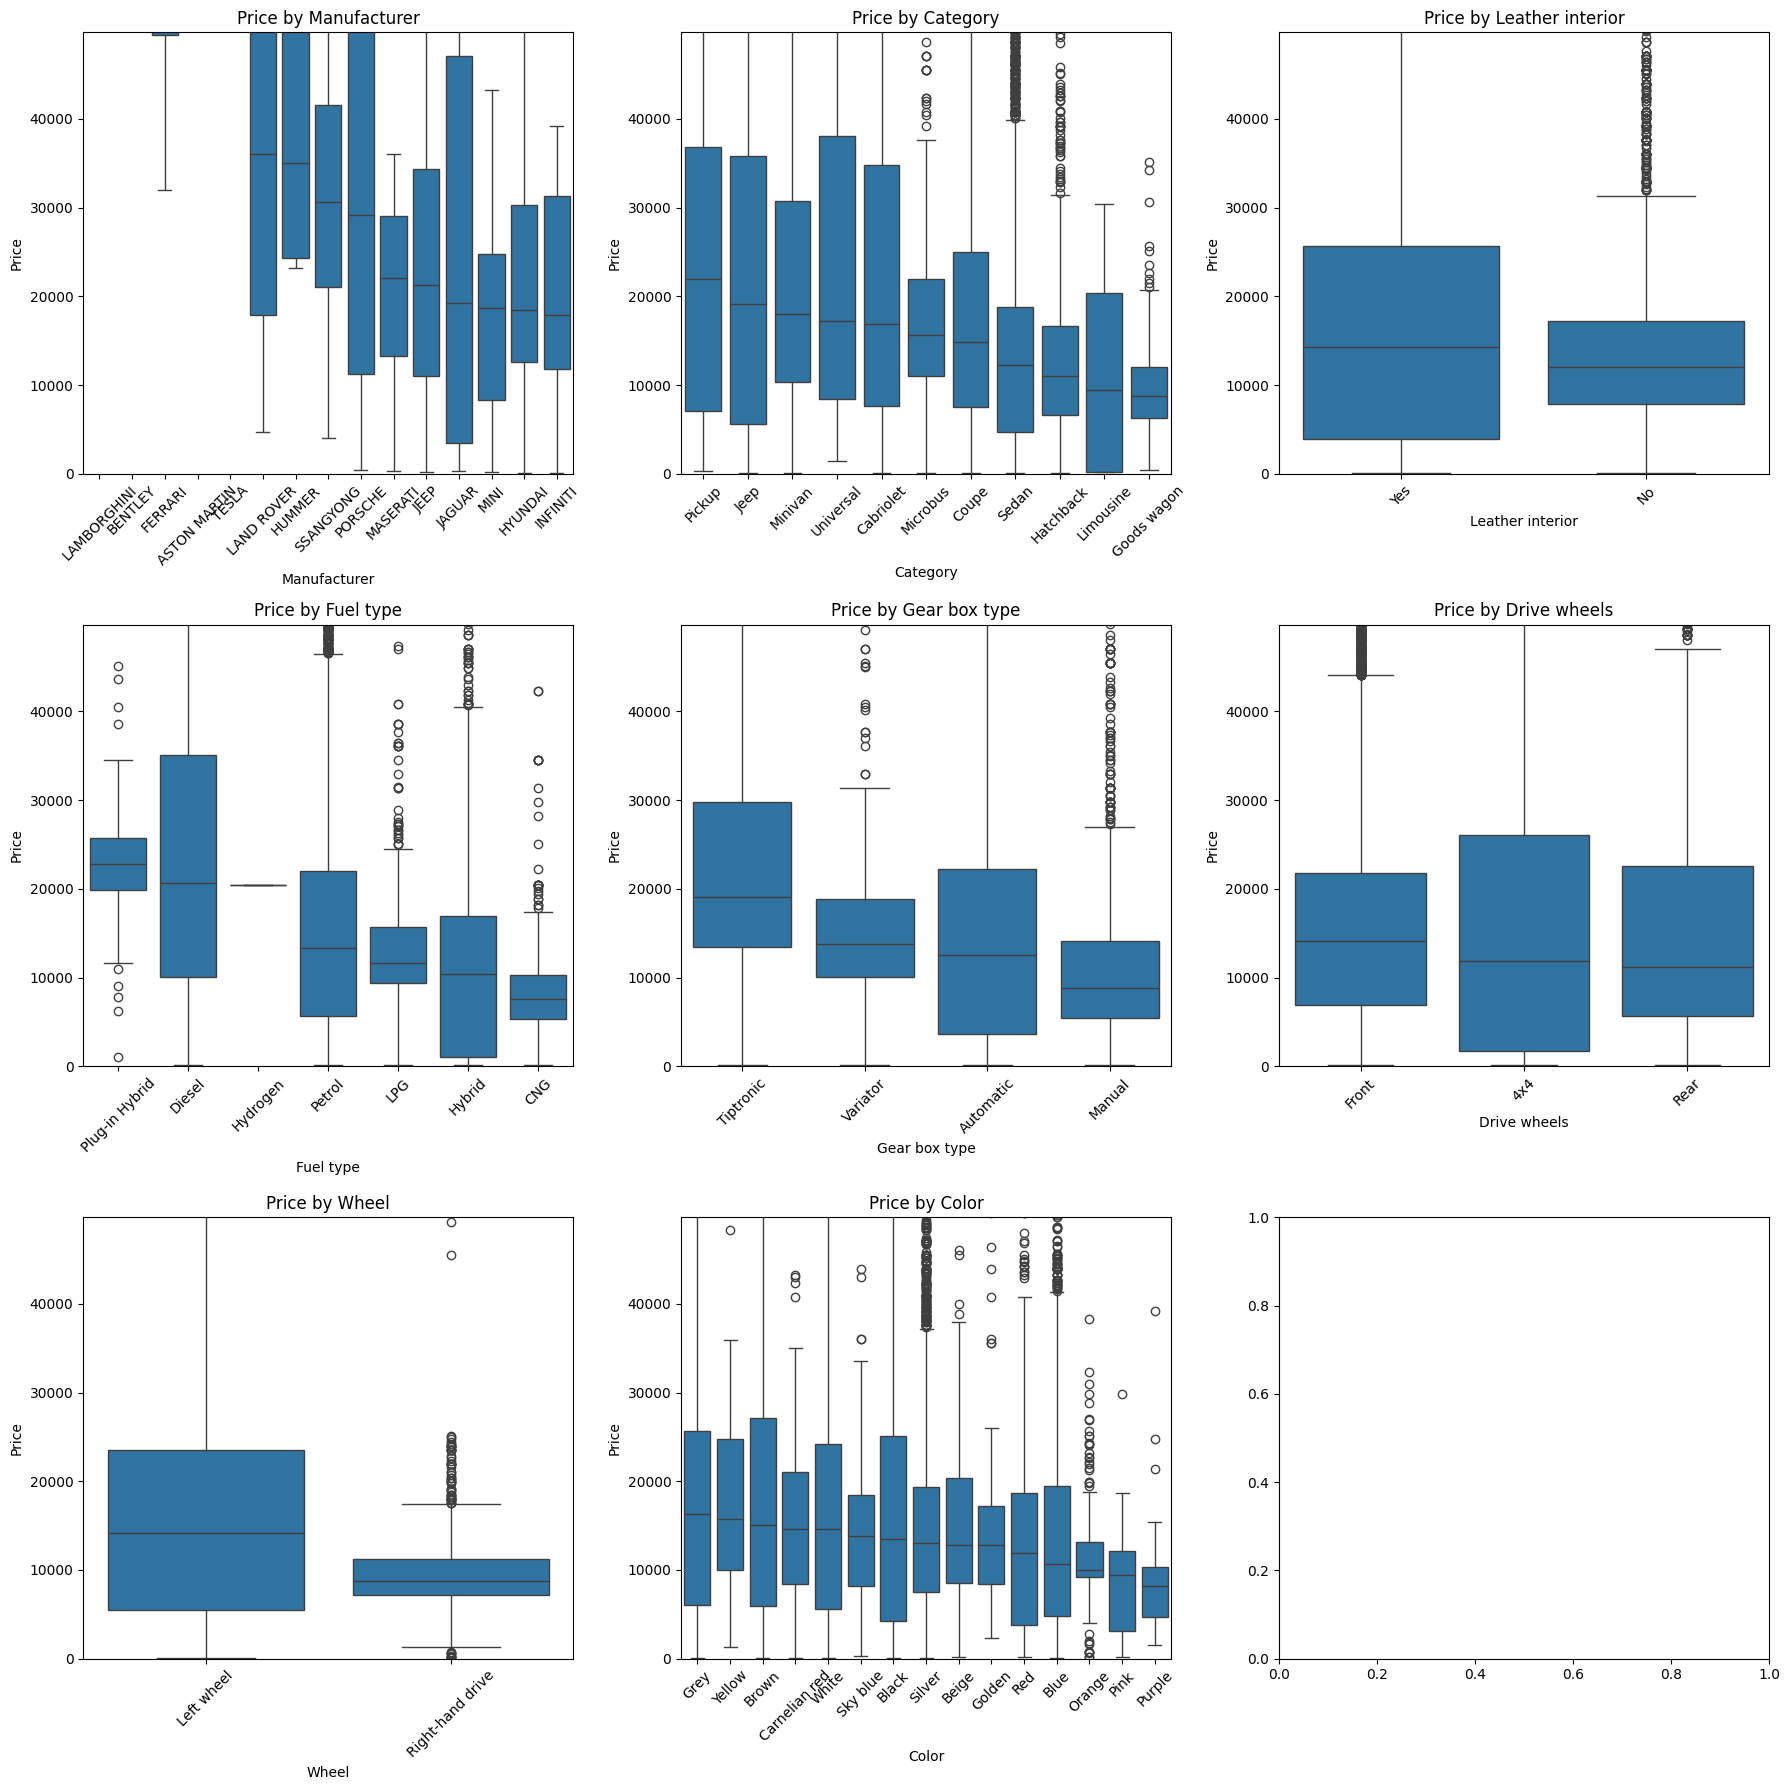

In [13]:
# Categorical feature distributions vs Price
cat_cols = train_clean.select_dtypes(include=['object', 'str']).columns.drop('Model')
##cat_cols = ['Manufacturer', 'Category', 'Fuel type', 'Gear box type', 'Drive wheels', 'Leather interior']

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
for ax, col in zip(axes.ravel(), cat_cols):
    # Show top categories by median price
    order = train_clean.groupby(train_df[col])['Price'].median().sort_values(ascending=False).index
    if len(order) > 15:
        order = order[:15]
    sns.boxplot(data=train_clean, x=train_df[col], y='Price', order=order, ax=ax)
    ax.set_title(f'Price by {col}')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, train_clean['Price'].quantile(0.95))
plt.tight_layout()
plt.show()

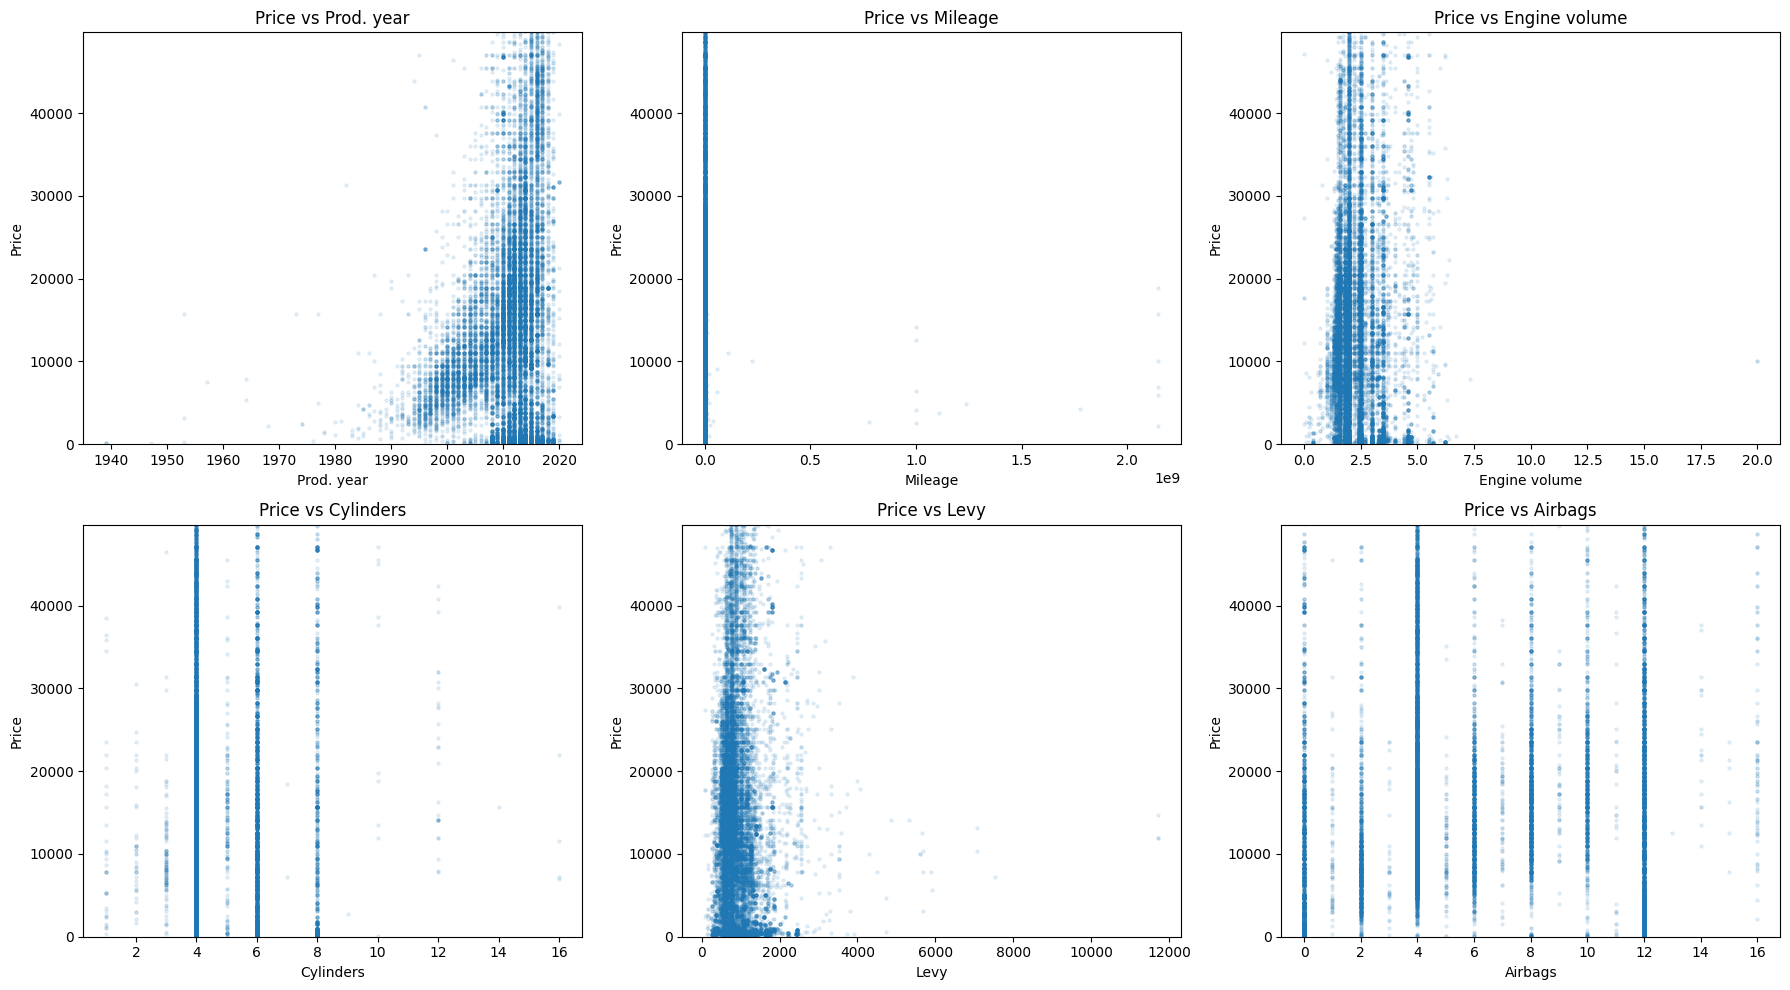

In [14]:
# Numeric feature scatter plots vs Price
num_features = ['Prod. year', 'Mileage', 'Engine volume', 'Cylinders', 'Levy', 'Airbags']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.ravel(), num_features):
    ax.scatter(train_clean[col], train_clean['Price'], alpha=0.1, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel('Price')
    ax.set_title(f'Price vs {col}')
    ax.set_ylim(0, train_clean['Price'].quantile(0.95))
plt.tight_layout()
plt.show()

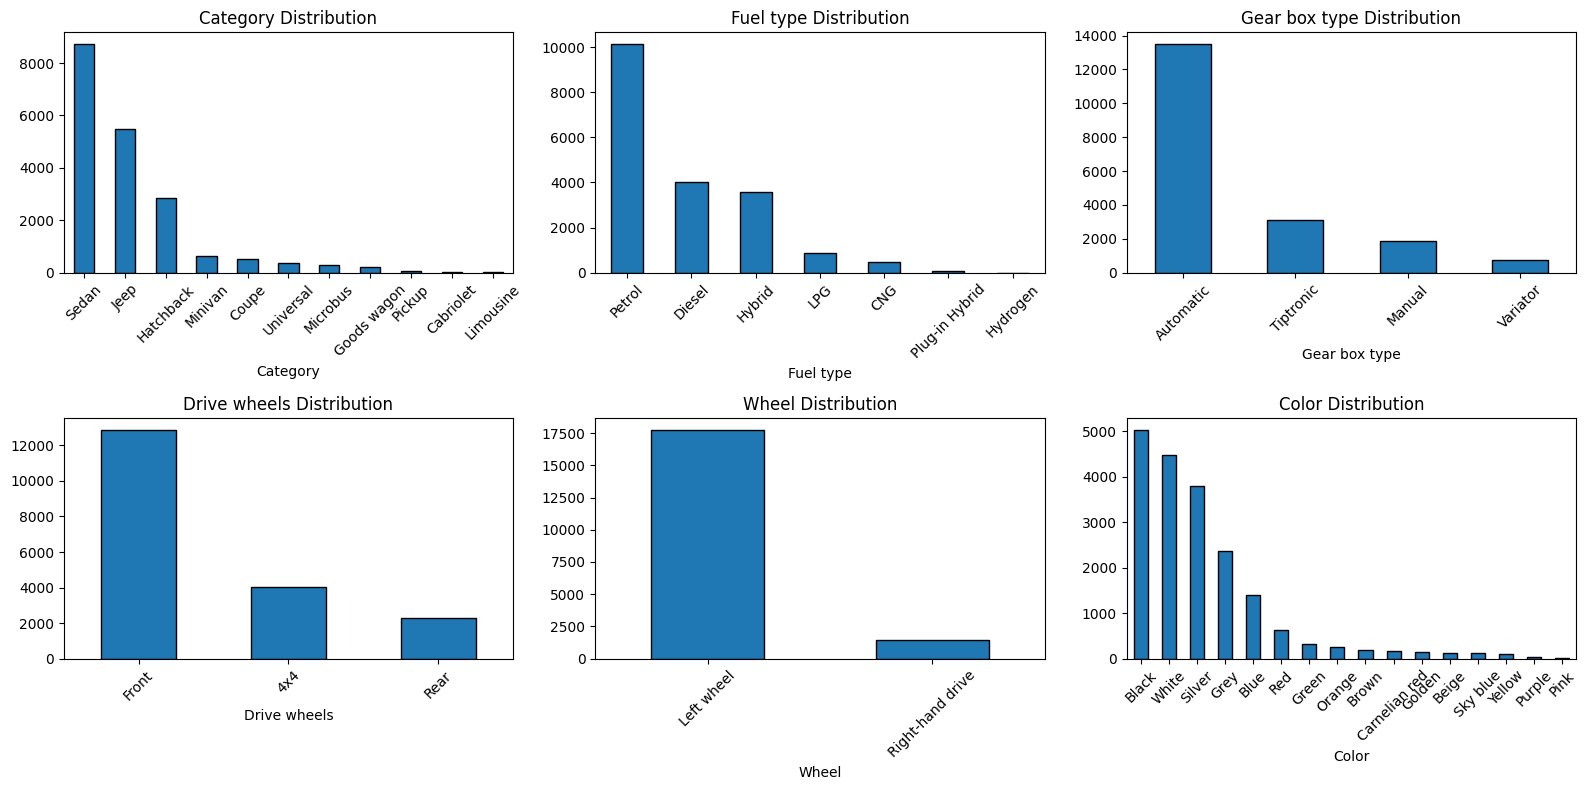

In [15]:
# Value counts for key categorical columns
cat_summary = ['Category', 'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Color']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), cat_summary):
    train_df[col].value_counts().plot.bar(ax=ax, edgecolor='black')
    ax.set_title(f'{col} Distribution')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

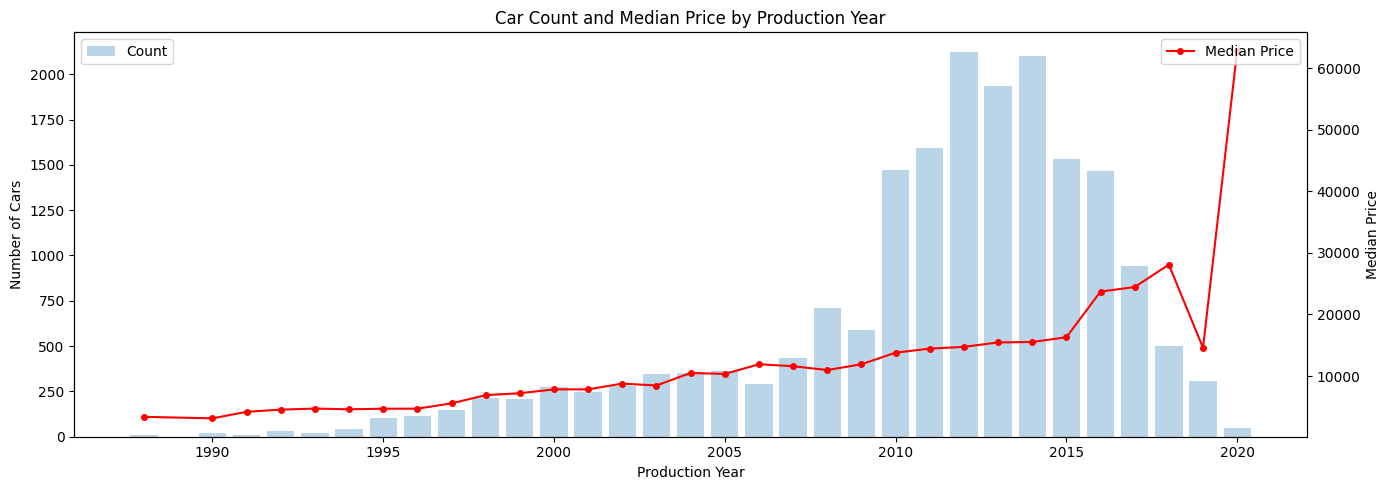

In [16]:
# Price by production year (age effect)
year_price = train_clean.groupby('Prod. year')['Price'].agg(['median', 'count']).reset_index()
year_price = year_price[year_price['count'] >= 10]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(year_price['Prod. year'], year_price['count'], alpha=0.3, label='Count')
ax1.set_ylabel('Number of Cars')
ax2 = ax1.twinx()
ax2.plot(year_price['Prod. year'], year_price['median'], 'r-o', markersize=4, label='Median Price')
ax2.set_ylabel('Median Price')
ax1.set_xlabel('Production Year')
ax1.set_title('Car Count and Median Price by Production Year')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [17]:
# Summary of potential data quality issues
print("=== Data Quality Summary ===\n")
print(f"Total training samples: {len(train_df)}")
print(f"Total test samples: {len(test_df)}")
print(f"\nLevy missing ('-'): {(train_df['Levy'] == '-').sum()} ({(train_df['Levy'] == '-').mean()*100:.1f}%)")
print(f"\nPrice outliers (>200k): {(train_df['Price'] > 200000).sum()}")
print(f"Price zeros: {(train_df['Price'] == 0).sum()}")
print(f"\nTop 10 Manufacturers:")
print(train_df['Manufacturer'].value_counts().head(10).to_string())
print(f"\nCategory breakdown:")
print(train_df['Category'].value_counts().to_string())

=== Data Quality Summary ===

Total training samples: 19237
Total test samples: 8245

Levy missing ('-'): 5819 (30.2%)

Price outliers (>200k): 13
Price zeros: 0

Top 10 Manufacturers:
Manufacturer
HYUNDAI          3769
TOYOTA           3662
MERCEDES-BENZ    2076
FORD             1111
CHEVROLET        1069
BMW              1049
LEXUS             982
HONDA             977
NISSAN            660
VOLKSWAGEN        579

Category breakdown:
Category
Sedan          8736
Jeep           5473
Hatchback      2847
Minivan         647
Coupe           532
Universal       364
Microbus        306
Goods wagon     233
Pickup           52
Cabriolet        36
Limousine        11


# Feature Engineering & Encoding

In [18]:
# Numeric columns in train_clean
num_cols = train_clean.select_dtypes(include=[np.number]).columns.drop(['ID', 'Prod. year', 'Price', 'Log_Price']).tolist()
print(f"Numeric columns ({len(num_cols)}):")
print(num_cols)
cat_cols = train_clean.select_dtypes(include=['object', 'str']).columns.drop('Model').tolist()
print(f"Categorical columns ({len(cat_cols)}):")
print(cat_cols)

Numeric columns (9):
['Levy', 'Engine volume', 'Mileage', 'Cylinders', 'Doors', 'Airbags', 'Age', 'Turbo', 'Levy_missing']
Categorical columns (8):
['Manufacturer', 'Category', 'Leather interior', 'Fuel type', 'Gear box type', 'Drive wheels', 'Wheel', 'Color']


In [19]:
from sklearn.preprocessing import LabelEncoder

# --- Encoding strategies ---
# For tree-based models (XGBoost/LightGBM): Label Encoding works well
# For linear models: One-Hot Encoding needed (but explodes dimensions with 'Model')

# Label Encode all categoricals (suitable for tree models)
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined train+test to handle unseen categories
    combined = pd.concat([train_clean[col], test_df[col]], axis=0).astype(str)
    le.fit(combined)
    train_clean[col + '_enc'] = le.transform(train_clean[col].astype(str))
    test_df[col + '_enc'] = le.transform(test_df[col].astype(str))
    label_encoders[col] = le

# Feature columns for modeling
feature_cols = num_cols + [c + '_enc' for c in cat_cols]

print(f"\nTotal features for modeling: {len(feature_cols)}")
print(f"\nSample encoded data:")
print(train_clean[feature_cols].head())


Total features for modeling: 17

Sample encoded data:
     Levy  Engine volume  Mileage  Cylinders  Doors  Airbags  Age  Turbo  \
0  1399.0            3.5   186005        6.0      5       12   16      0   
1  1018.0            3.0   192000        6.0      5        8   15      0   
2   574.0            1.3   200000        4.0      5        2   20      0   
3   862.0            2.5   168966        4.0      5        0   15      0   
4   446.0            1.3    91901        4.0      5        4   12      0   

   Levy_missing  Manufacturer_enc  Category_enc  Leather interior_enc  \
0             0                33             4                     1   
1             0                 8             4                     0   
2             1                22             3                     0   
3             0                16             4                     1   
4             0                22             3                     1   

   Fuel type_enc  Gear box type_enc  Drive wheels

### Target Encoding for Manufacturer and Model

In [20]:
# Label-encode Model as well (high cardinality) for tree models
le_model = LabelEncoder()
combined_model = pd.concat([train_clean['Model'], test_df['Model']], axis=0).astype(str)
le_model.fit(combined_model)
train_clean['Model_enc'] = le_model.transform(train_clean['Model'].astype(str))
test_df['Model_enc'] = le_model.transform(test_df['Model'].astype(str))

In [21]:
# Prepare final X, y arrays
target = 'Log_Price'

# Config B won: label encoding for Model is best
feature_cols = num_cols + [c + '_enc' for c in cat_cols] + ['Model_enc']

X_train = train_clean[feature_cols].copy()
y_train = train_clean[target].copy()
X_test = test_df[feature_cols].copy()

# Check for any remaining issues
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nFeature columns ({len(feature_cols)}):")
print(feature_cols)
print(f"\nMissing in X_train:\n{X_train.isnull().sum()[X_train.isnull().sum() > 0]}")
print(f"\nMissing in X_test:\n{X_test.isnull().sum()[X_test.isnull().sum() > 0]}")

X_train shape: (18881, 18)
X_test shape: (8245, 18)
y_train shape: (18881,)

Feature columns (18):
['Levy', 'Engine volume', 'Mileage', 'Cylinders', 'Doors', 'Airbags', 'Age', 'Turbo', 'Levy_missing', 'Manufacturer_enc', 'Category_enc', 'Leather interior_enc', 'Fuel type_enc', 'Gear box type_enc', 'Drive wheels_enc', 'Wheel_enc', 'Color_enc', 'Model_enc']

Missing in X_train:
Series([], dtype: int64)

Missing in X_test:
Series([], dtype: int64)


# Modeling

In [22]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define models to compare
models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=500, max_depth=8, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1),
}

# Evaluate each model with CV (scoring = neg RMSE on log scale)
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    results[name] = {'RMSE': -scores.mean(), 'STD': scores.std()}
    print(f"{name:15} | RMSE: {-scores.mean():.4f} ± {scores.std():.4f}")

print("\n(RMSE is on log-price scale. Lower is better.)")

/Users/carriezhang/Documents/Coding/Trading Backtest/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.787770709155868e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/carriezhang/Documents/Coding/Trading Backtest/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.833734637812838e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/carriezhang/Documents/Coding/Trading Backtest/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.565575652751555e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/carriezhang/Documents/Coding/Trading Backtest/.venv/lib/python3.14/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-condi

Ridge           | RMSE: 1.2757 ± 0.0183
Random Forest   | RMSE: 0.7341 ± 0.0247
XGBoost         | RMSE: 0.7439 ± 0.0238
LightGBM        | RMSE: 0.7580 ± 0.0242

(RMSE is on log-price scale. Lower is better.)


Best model: Random Forest (RMSE: 0.7341)


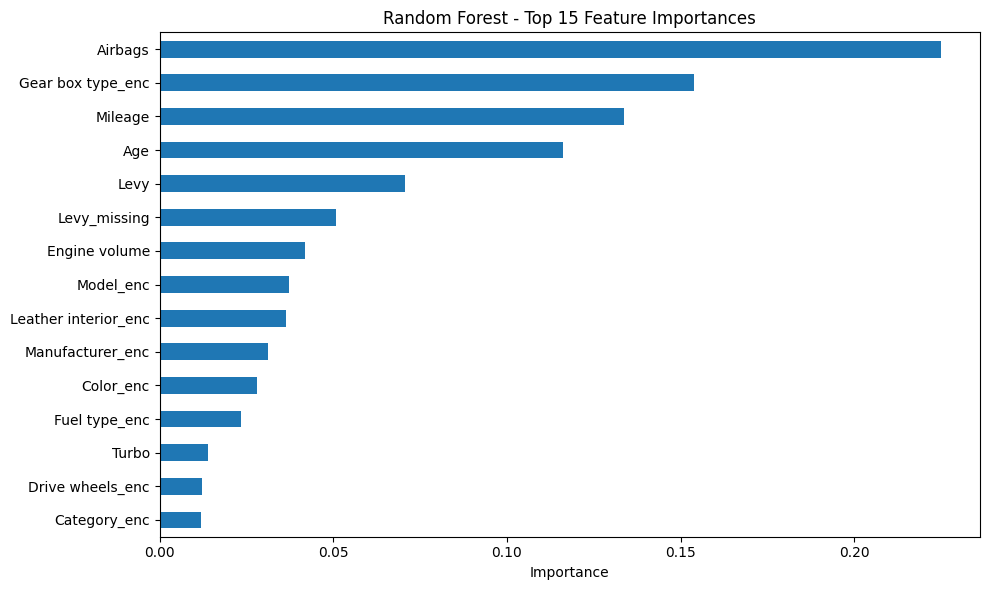

In [23]:
# Train the best model on full training data and check feature importance
best_model_name = min(results, key=lambda k: results[k]['RMSE'])
print(f"Best model: {best_model_name} (RMSE: {results[best_model_name]['RMSE']:.4f})")

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    importance.head(15).plot.barh()
    plt.title(f'{best_model_name} - Top 15 Feature Importances')
    plt.xlabel('Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [24]:
# Generate predictions and create submission
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)   # Back-transform from log scale
y_pred = np.maximum(y_pred, 0)  # Ensure no negative prices

# Create submission file
submission = pd.DataFrame({'ID': test_df['ID'], 'Price': y_pred.astype(int)})
submission.to_csv('submission_random_forest.csv', index=False)

print(f"Submission shape: {submission.shape}")
print(f"Prediction stats:\n{submission['Price'].describe()}")
print("\nFirst 5 predictions:")
print(submission.head())

Submission shape: (8245, 2)
Prediction stats:
count      8245.000000
mean      14995.785203
std       14485.056650
min         109.000000
25%        5018.000000
50%       12109.000000
75%       18733.000000
max      178729.000000
Name: Price, dtype: float64

First 5 predictions:
         ID  Price
0  44020629  13739
1  45784798  10983
2  45800257   7560
3  45797981   2850
4  45814303   3337


# Hyperparameter Tuning with Optuna

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score, KFold
optuna.logging.set_verbosity(optuna.logging.WARNING)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Tune LightGBM ---
def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }
    model = lgb.LGBMRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

print("Tuning LightGBM (50 trials)...")
lgb_study = optuna.create_study(direction='minimize')
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest LightGBM RMSE: {lgb_study.best_value:.4f}")
print(f"Best params: {lgb_study.best_params}")

In [ ]:
# --- Tune XGBoost ---
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'random_state': 42,
        'n_jobs': -1,
    }
    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

print("Tuning XGBoost (50 trials)...")
xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\nBest XGBoost RMSE: {xgb_study.best_value:.4f}")
print(f"Best params: {xgb_study.best_params}")

In [ ]:
# --- Train tuned models and blend predictions ---
print("Training tuned LightGBM...")
lgb_best = lgb.LGBMRegressor(**lgb_study.best_params, random_state=42, n_jobs=-1, verbose=-1)
lgb_best.fit(X_train, y_train)

print("Training tuned XGBoost...")
xgb_best = xgb.XGBRegressor(**xgb_study.best_params, random_state=42, n_jobs=-1)
xgb_best.fit(X_train, y_train)

# Blend predictions (0.5 x LGB + 0.5 x XGB)
lgb_pred = lgb_best.predict(X_test)
xgb_pred = xgb_best.predict(X_test)
blended_pred_log = 0.5 * lgb_pred + 0.5 * xgb_pred
blended_pred = np.expm1(blended_pred_log)
blended_pred = np.maximum(blended_pred, 0)

# Also check blended CV score
from sklearn.model_selection import cross_val_predict
lgb_cv_pred = cross_val_predict(lgb_best, X_train, y_train, cv=kf)
xgb_cv_pred = cross_val_predict(xgb_best, X_train, y_train, cv=kf)
blended_cv = 0.5 * lgb_cv_pred + 0.5 * xgb_cv_pred
blended_rmse = np.sqrt(mean_squared_error(y_train, blended_cv))

print(f"\nBlended CV RMSE: {blended_rmse:.4f}")
print(f"LightGBM best:   {lgb_study.best_value:.4f}")
print(f"XGBoost best:    {xgb_study.best_value:.4f}")
print(f"\nBlend improvement: {min(lgb_study.best_value, xgb_study.best_value) - blended_rmse:.4f}")

In [ ]:
# Create final blended submission
final_submission = pd.DataFrame({'ID': test_df['ID'], 'Price': blended_pred.astype(int)})
final_submission.to_csv('submission_blended.csv', index=False)

print(f"Final submission shape: {final_submission.shape}")
print(f"Prediction stats:\n{final_submission['Price'].describe()}")
print("\nFirst 5 predictions:")
print(final_submission.head())